# Flight Delay Classifier

Predict whether a flight will be delayed (`Delay` = 1) from its airline, airports, day of week, departure time and scheduled length.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Data Collection

In [2]:
df = pd.read_csv("Airlines.csv")
print(df.shape)
df.head()

(539383, 9)


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


In [3]:
df.info()
# isna() -> True/False per cell; 1st sum() -> nulls per column; 2nd sum() -> total across all columns
print("\nNulls:", df.isna().sum().sum())
print("Duplicate rows (ignoring id):", df.drop(columns="id").duplicated().sum()) # id is irrelevant for predicting delays

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539383 entries, 0 to 539382
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           539383 non-null  int64 
 1   Airline      539383 non-null  object
 2   Flight       539383 non-null  int64 
 3   AirportFrom  539383 non-null  object
 4   AirportTo    539383 non-null  object
 5   DayOfWeek    539383 non-null  int64 
 6   Time         539383 non-null  int64 
 7   Length       539383 non-null  int64 
 8   Delay        539383 non-null  int64 
dtypes: int64(6), object(3)
memory usage: 37.0+ MB

Nulls: 0
Duplicate rows (ignoring id): 216618


No nulls but there about 216,618 rows are exact duplicates once `id` is ignored. However, these are most likely the same recurring flight happening on different days.

## 2. Exploratory Data Analysis

Delayed: 44.5%  |  On time: 55.5%


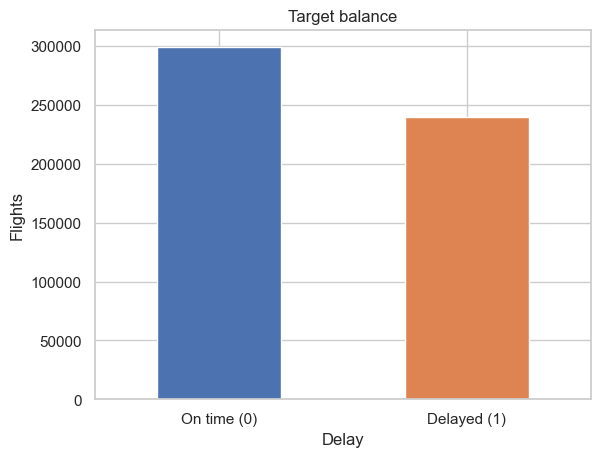

In [4]:
rate = df["Delay"].mean()
print(f"Delayed: {rate:.1%}  |  On time: {1 - rate:.1%}")
ax = df["Delay"].value_counts().sort_index().plot.bar(color=["#4C72B0", "#DD8452"])
ax.set(title="Target balance", xticklabels=["On time (0)", "Delayed (1)"], ylabel="Flights")
plt.xticks(rotation=0); plt.show()

The data already shows that 55.5% of the time, predicting a flight is on time is the correct answer. This means the models have to be at least accurate 55.5% of the time or better.

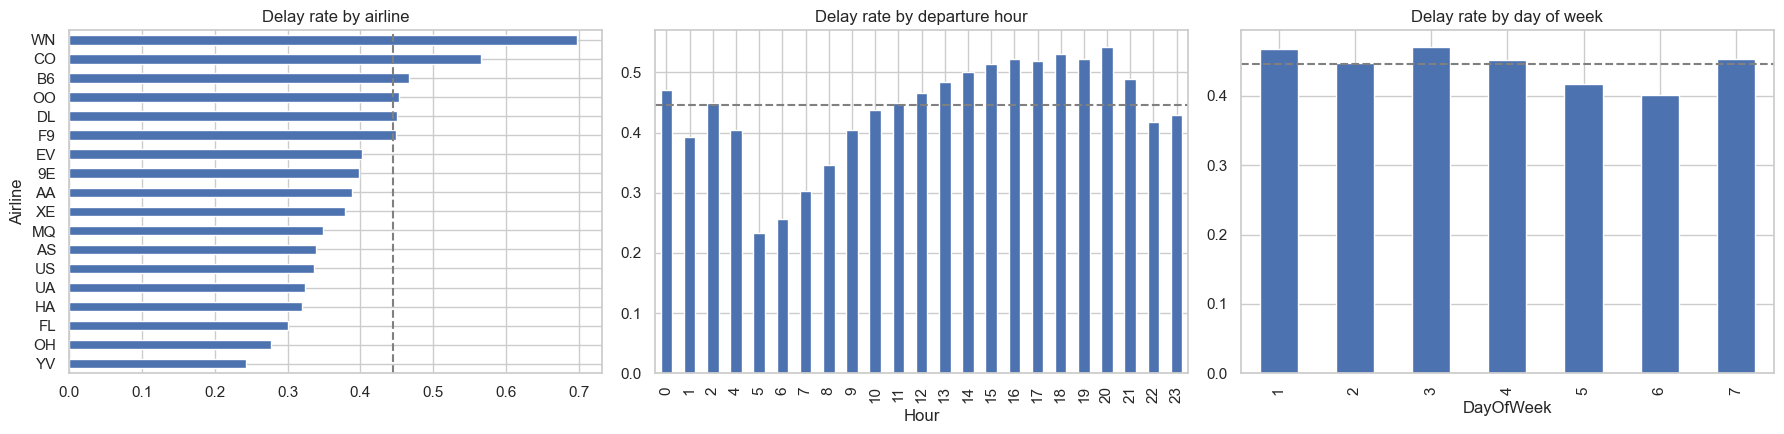

In [5]:
df["Hour"] = df["Time"] // 60  # Time is minutes after midnight

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
by_airline = df.groupby("Airline")["Delay"].mean().sort_values()
by_airline.plot.barh(ax=axes[0], color="#4C72B0", title="Delay rate by airline")
df.groupby("Hour")["Delay"].mean().plot.bar(ax=axes[1], color="#4C72B0", title="Delay rate by departure hour")
df.groupby("DayOfWeek")["Delay"].mean().plot.bar(ax=axes[2], color="#4C72B0", title="Delay rate by day of week")
axes[0].axvline(rate, ls="--", c="gray")  # dashed line = overall delay rate
for ax in axes[1:]:
    ax.axhline(rate, ls="--", c="gray")
plt.tight_layout(); plt.show()

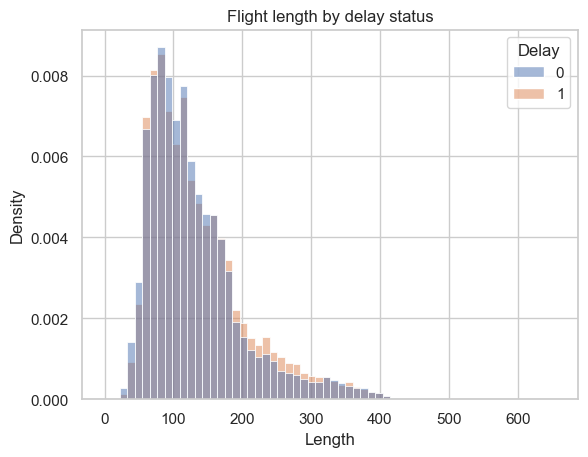

In [6]:
sns.histplot(data=df, x="Length", hue="Delay", bins=60, stat="density", common_norm=False)
plt.title("Flight length by delay status"); plt.show()

In [7]:
top_airports = df.groupby("AirportFrom")["Delay"].agg(["mean", "size"]).query("size > 5000").sort_values("mean")
print("Busiest origin airports, lowest and highest delay rates:")
pd.concat([top_airports.head(5), top_airports.tail(5)])

Busiest origin airports, lowest and highest delay rates:


,mean,size
AirportFrom,,
DCA,0.317121,7073
MEM,0.320775,6450
LGA,0.354978,8547
TPA,0.384552,6085
IAD,0.385723,6528
SAN,0.534066,6370
LAS,0.559993,11918
STL,0.568475,5031
BWI,0.573263,8565


The biggest factor in whether a flight is delayed is the airline: Southwest (WN) flights are late about 70% of the time, while YV flights are late only about 24% of the time. Departure time matters, because delays build up over the day, from about 25% of early-morning flights to 50% or more in the evening. The airport also has a strong effect, with busy hubs differing from each other by more than 20 percentage points. Id and Flight are just labels that say nothing about whether a flight will be late, so drop them.

## 3. Feature extraction
- Keep Airline, AirportFrom, AirportTo (categorical) and DayOfWeek, Hour, Length (numeric).
- Linear models get one-hot categoricals plus scaled numerics.
  - Airline is a label like WN, AA, DL, so it has to become numbers first. If we just numbered them (WN=0, AA=1, DL=2), the model would treat that as a scale: DL would count as "twice AA", and the numbers would mean something they don't. There's no real order or distance between airlines.
  - One-hot gives each airline its own 0/1 column ("is this WN?", "is this AA?"). Each airline then gets its own weight, which is the effect we want: WN pushes delay up, YV pushes it down, with no fake ordering.
- Tree models get ordinal codes. HistGradientBoosting treats the codes as true categories. It supports at most 255 categories per feature, so the rarest airports are grouped into one "infrequent" bucket.
  - An ordinal code is just a number assigned to each category (WN=0, AA=1, DL=2, ...), one column per feature. Airlines have no real order, so here the numbers are only ID tags.
  - Trees can use them because a tree never does math on the value. It only asks questions like "is the code ≤ 5?" and splits, so the arbitrary numbering is harmless. Several splits in a row can isolate any airline or group of airlines. HistGradientBoosting goes further and splits by choosing which categories go left and right, so the order doesn't matter at all.
  - Trees benefit because it keeps the data compact. One-hot would turn the airports into hundreds of columns, which is slower and gives trees weaker splits. One column of codes does the same job.

In [8]:
CAT = ["Airline", "AirportFrom", "AirportTo"]
NUM = ["DayOfWeek", "Hour", "Length"]

X = df[CAT + NUM]
y = df["Delay"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")

onehot = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
    ("num", StandardScaler(), NUM),
])
ordinal = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, max_categories=255), CAT),
    ("num", "passthrough", NUM),
])

Train: 431,506  Test: 107,877


## 4. Model training
We try three models, from simple to complex, to see what each step up adds:

- Logistic Regression: a simple, interpretable starting point. It outputs a probability of delay.
- Random Forest: many decision trees averaged together. It can pick up non-linear effects and interactions, like airline × hour, that a linear model can't.
- HistGradientBoosting: trees built one after another, each fixing the last one's mistakes. It's usually the strongest classical model on tabular data, and it's fast.

In [9]:
# make_pipeline chains the encoder and the model.
models = {
    "Logistic Regression": make_pipeline(onehot, LogisticRegression(max_iter=1000)),
    "Random Forest": make_pipeline(ordinal, RandomForestClassifier(
        n_estimators=100, max_depth=20, min_samples_leaf=20, n_jobs=-1, random_state=RANDOM_STATE)),
    "HistGradientBoosting": make_pipeline(ordinal, HistGradientBoostingClassifier(
        categorical_features=[0, 1, 2], random_state=RANDOM_STATE)),
}

def score(model, X):
    """Probability of delay."""
    return model.predict_proba(X)[:, 1]

results, scores = [], {}
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    fit_s = time.time() - start
    s = score(model, X_test)
    pred = (s >= 0.5).astype(int)
    scores[name] = s
    results.append({"Model": name, "Accuracy": accuracy_score(y_test, pred),
                    "ROC-AUC": roc_auc_score(y_test, s), "F1": f1_score(y_test, pred),
                    "Fit time (s)": fit_s})
    print(f"{name:<24} done in {fit_s:.1f}s")

results = pd.DataFrame(results).set_index("Model").round(4)
results

Logistic Regression      done in 1.9s


Random Forest            done in 7.0s


HistGradientBoosting     done in 3.1s


,Accuracy,ROC-AUC,F1,Fit time (s)
Model,,,,
Logistic Regression,0.6462,0.6911,0.5502,1.8522
Random Forest,0.6696,0.7204,0.5752,7.0383
HistGradientBoosting,0.6683,0.7201,0.5823,3.1284


## 5. Model evaluation
Random Forest had the best ROC-AUC (0.7204), so we evaluate it further below.

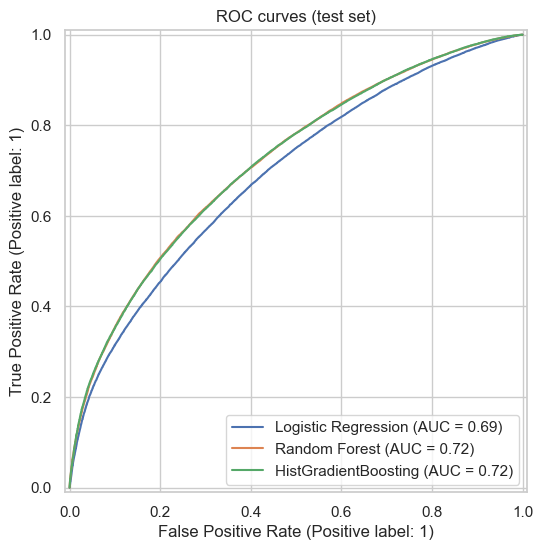

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, s in scores.items():
    RocCurveDisplay.from_predictions(y_test, s, name=name, ax=ax)
ax.set_title("ROC curves (test set)"); plt.show()

Best model by ROC-AUC: Random Forest 



              precision    recall  f1-score   support

     On time       0.67      0.80      0.73     59824
     Delayed       0.67      0.50      0.58     48053

    accuracy                           0.67    107877
   macro avg       0.67      0.65      0.65    107877
weighted avg       0.67      0.67      0.66    107877



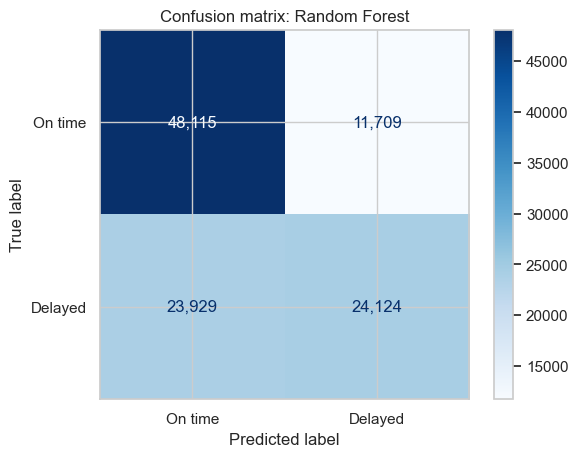

In [11]:
best_name = results["ROC-AUC"].idxmax()
best = models[best_name]
best_pred = (scores[best_name] >= 0.5).astype(int)
print("Best model by ROC-AUC:", best_name, "\n")
print(classification_report(y_test, best_pred, target_names=["On time", "Delayed"]))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=["On time", "Delayed"],
                                        cmap="Blues", values_format=",")
plt.title(f"Confusion matrix: {best_name}"); plt.show()

In [12]:
import joblib

# Save the best pipeline plus the dropdown options for the Streamlit app (app.py).
airlines, airports_from, _ = best[0].named_transformers_["cat"].categories_
joblib.dump({"model": best, "airlines": airlines.tolist(), "airports": airports_from.tolist()},
            "model.joblib", compress=3)

['model.joblib']

Random Forest reaches 0.72 ROC-AUC and 67% accuracy, clearly above the 55.5% baseline. It classifies on-time flights well (recall 0.80) but catches only half of the real delays (recall 0.50).